In [ ]:
import gym
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import deque
import random

# Создаем среду
env = gym.make("MountainCar-v0")
n_action = env.action_space.n

print(f"Количество действий: {n_action}")
print(f"Диапазон состояний: {env.observation_space.low} - {env.observation_space.high}")

state = env.reset()
print(f"Начальное состояние: {state}")

Количество действий: 3
Диапазон состояний: [-1.2  -0.07] - [0.6  0.07]
Начальное состояние: [-0.50105363  0.        ]


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


Реализация Q-обучения с линейной аппроксимацией

Эпизод 10, Награда: -200.0
Эпизод 20, Награда: -200.0
Эпизод 30, Награда: -183.0
Эпизод 40, Награда: -200.0
Эпизод 50, Награда: -200.0
Эпизод 60, Награда: -200.0
Эпизод 70, Награда: -195.0
Эпизод 80, Награда: -142.0
Эпизод 90, Награда: -177.0
Эпизод 100, Награда: -166.0
Эпизод 110, Награда: -167.0
Эпизод 120, Награда: -200.0
Эпизод 130, Награда: -135.0
Эпизод 140, Награда: -200.0
Эпизод 150, Награда: -200.0
Эпизод 160, Награда: -147.0
Эпизод 170, Награда: -200.0
Эпизод 180, Награда: -130.0
Эпизод 190, Награда: -200.0
Эпизод 200, Награда: -200.0
Эпизод 210, Награда: -161.0
Эпизод 220, Награда: -191.0
Эпизод 230, Награда: -138.0
Эпизод 240, Награда: -145.0
Эпизод 250, Награда: -140.0
Эпизод 260, Награда: -133.0
Эпизод 270, Награда: -200.0
Эпизод 280, Награда: -149.0
Эпизод 290, Награда: -131.0
Эпизод 300, Награда: -121.0
Эпизод 310, Награда: -146.0
Эпизод 320, Награда: -142.0
Эпизод 330, Награда: -156.0
Эпизод 340, Награда: -159.0
Эпизод 350, Награда: -173.0
Эпизод 360, Награда: -125.0
Э

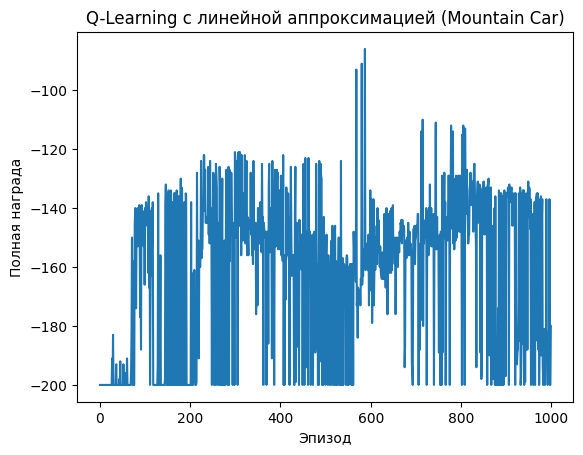

In [ ]:
class Estimator():
    def __init__(self, n_feat, n_state, n_action, lr=0.05):
        self.n_feat = n_feat
        # Генерируем случайные веса для формирования признаков
        torch.manual_seed(0)
        # w должен быть (n_state, n_feat) для матричного умножения s @ w
        self.w = torch.randn((n_state, n_feat)) * 5.0
        self.b = torch.rand(n_feat) * 2.0 * math.pi

        self.models = []
        self.optimizers = []
        self.criterion = torch.nn.MSELoss()

        for _ in range(n_action):
            model = torch.nn.Linear(n_feat, 1)
            self.models.append(model)
            self.optimizers.append(torch.optim.SGD(model.parameters(), lr))

    def get_feature(self, s):
        """Превращает состояние в вектор признаков размерности n_feat"""
        # БЕЗОПАСНОЕ ИЗВЛЕЧЕНИЕ СОСТОЯНИЯ (для новых версий Gym)
        if isinstance(s, tuple):
            s = s[0]

        # Превращаем s в тензор 1D (вектор)
        s_tensor = torch.as_tensor(s).float().view(-1)

        # Вычисляем признаки: cos(s * w + b)
        # s_tensor (1, n_state) @ w (n_state, n_feat) = (1, n_feat)
        features = (2.0 / self.n_feat) ** .5 * torch.cos(torch.matmul(s_tensor, self.w) + self.b)
        return features

    def update(self, s, a, y):
        """Обучает модель для действия 'a' на целевом значении 'y'"""
        features = self.get_feature(s)
        y_pred = self.models[a](features)
        loss = self.criterion(y_pred, torch.tensor([y]).float())

        self.optimizers[a].zero_grad()
        loss.backward()
        self.optimizers[a].step()

    def predict(self, s):
        """Возвращает Q-значения для всех действий в состоянии s"""
        features = self.get_feature(s)
        with torch.no_grad():
            return torch.tensor([model(features).item() for model in self.models])

def gen_epsilon_greedy_policy(estimator, epsilon, n_action):
    def policy_function(state):
        probs = torch.ones(n_action) * epsilon / n_action
        q_values = estimator.predict(state)
        best_action = torch.argmax(q_values).item()
        probs[best_action] += 1.0 - epsilon
        action = torch.multinomial(probs, 1).item()
        return action
    return policy_function

def q_learning(env, estimator, n_episode, gamma=1.0, epsilon=0.1, epsilon_decay=.99):
    total_reward_episode = []

    for episode in range(n_episode):
        curr_epsilon = epsilon * (epsilon_decay ** episode)
        policy = gen_epsilon_greedy_policy(estimator, curr_epsilon, n_action)

        # СБРОС СРЕДЫ (учитываем кортеж в новых версиях)
        state_info = env.reset()
        state = state_info[0] if isinstance(state_info, tuple) else state_info

        is_done = False
        total_reward = 0

        while not is_done:
            action = policy(state)

            # ШАГ В СРЕДЕ (учитываем 4 или 5 значений)
            step_res = env.step(action)
            next_state = step_res[0]
            reward = step_res[1]

            # Логика завершения (совместимость с Gymnasium)
            if len(step_res) == 5:
                terminated, truncated = step_res[2], step_res[3]
                is_done = terminated or truncated
            else:
                is_done = step_res[2]

            # Вычисляем цель (TD Target)
            q_values_next = estimator.predict(next_state)
            td_target = reward + gamma * torch.max(q_values_next).item()

            # Обновляем веса
            estimator.update(state, action, td_target)

            total_reward += reward
            state = next_state

        total_reward_episode.append(total_reward)
        if (episode + 1) % 10 == 0:
            print(f"Эпизод {episode+1}, Награда: {total_reward}")

    return total_reward_episode

# ЗАПУСК
env = gym.make("MountainCar-v0")
n_state = env.observation_space.shape[0]
n_action = env.action_space.n

estimator = Estimator(n_feat=200, n_state=n_state, n_action=n_action, lr=0.03)
rewards = q_learning(env, estimator, n_episode=1000)

# Визуализация
plt.plot(rewards)
plt.title('Q-Learning с линейной аппроксимацией (Mountain Car)')
plt.xlabel('Эпизод')
plt.ylabel('Полная награда')
plt.show()

Реализация SARSA с линейной аппроксимацией

SARSA Эпизод 50, Награда: -200.0
SARSA Эпизод 100, Награда: -200.0
SARSA Эпизод 150, Награда: -136.0
SARSA Эпизод 200, Награда: -140.0
SARSA Эпизод 250, Награда: -135.0
SARSA Эпизод 300, Награда: -200.0
SARSA Эпизод 350, Награда: -148.0
SARSA Эпизод 400, Награда: -164.0
SARSA Эпизод 450, Награда: -141.0
SARSA Эпизод 500, Награда: -145.0
SARSA Эпизод 550, Награда: -188.0
SARSA Эпизод 600, Награда: -153.0
SARSA Эпизод 650, Награда: -153.0
SARSA Эпизод 700, Награда: -148.0
SARSA Эпизод 750, Награда: -133.0
SARSA Эпизод 800, Награда: -132.0
SARSA Эпизод 850, Награда: -144.0
SARSA Эпизод 900, Награда: -134.0
SARSA Эпизод 950, Награда: -199.0
SARSA Эпизод 1000, Награда: -141.0


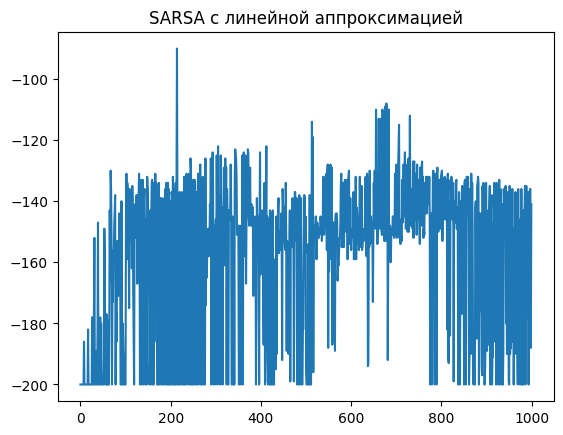

In [ ]:
def sarsa(env, estimator, n_episode, gamma=1.0, epsilon=0.1, epsilon_decay=.99):
    total_reward_episode = []

    for episode in range(n_episode):
        curr_epsilon = epsilon * (epsilon_decay ** episode)
        policy = gen_epsilon_greedy_policy(estimator, curr_epsilon, n_action)

        # Сброс среды
        res = env.reset()
        state = res[0] if isinstance(res, tuple) else res

        # В SARSA нужно выбрать первое действие ДО начала цикла
        action = policy(state)
        is_done = False
        total_reward = 0

        while not is_done:
            # Шаг в среде
            step_res = env.step(action)
            next_state = step_res[0]
            reward = step_res[1]

            if len(step_res) == 5:
                terminated, truncated = step_res[2], step_res[3]
                is_done = terminated or truncated
            else:
                is_done = step_res[2]

            # В SARSA выбираем СЛЕДУЮЩЕЕ действие сейчас
            next_action = policy(next_state)

            # Вычисляем Q-значения для следующего состояния
            q_values_next = estimator.predict(next_state)

            # ЦЕЛЬ TD для SARSA: r + gamma * Q(s', a')
            td_target = reward + gamma * q_values_next[next_action].item()

            # Обновление
            estimator.update(state, action, td_target)

            total_reward += reward
            state = next_state
            action = next_action # Переходим к следующему действию

        total_reward_episode.append(total_reward)
        if (episode + 1) % 50 == 0:
            print(f"SARSA Эпизод {episode+1}, Награда: {total_reward}")

    return total_reward_episode

# Запуск SARSA
estimator_sarsa = Estimator(200, n_state, n_action, lr=0.03)
rewards_sarsa = sarsa(env, estimator_sarsa, n_episode=1000)

plt.plot(rewards_sarsa)
plt.title('SARSA с линейной аппроксимацией')
plt.show()

Q-обучение с буфером воспроизведения опыта (Experience Replay)

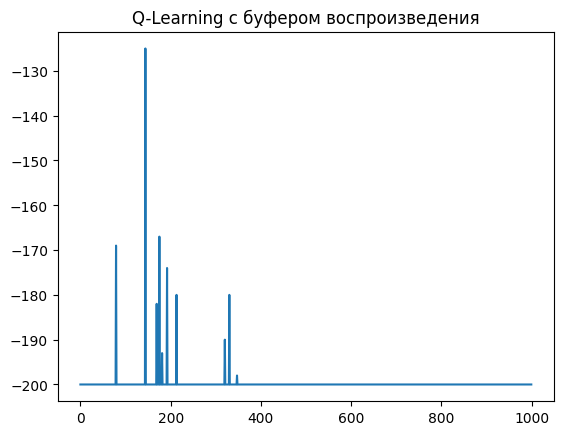

In [ ]:
from collections import deque
import random

memory = deque(maxlen=400) # Буфер памяти

def q_learning_replay(env, estimator, n_episode, replay_size, gamma=1.0, epsilon=0.1, epsilon_decay=0.99):
    total_reward_episode = []

    for episode in range(n_episode):
        curr_epsilon = epsilon * (epsilon_decay ** episode)
        policy = gen_epsilon_greedy_policy(estimator, curr_epsilon, n_action)

        res = env.reset()
        state = res[0] if isinstance(res, tuple) else res
        is_done = False
        total_reward = 0

        while not is_done:
            action = policy(state)
            step_res = env.step(action)
            next_state, reward = step_res[0], step_res[1]

            if len(step_res) == 5:
                is_done = step_res[2] or step_res[3]
            else:
                is_done = step_res[2]

            total_reward += reward

            # Вычисляем цель
            q_values_next = estimator.predict(next_state)
            td_target = reward + gamma * torch.max(q_values_next).item()

            # Сохраняем опыт в память (состояние, действие, цель)
            # Важно сохранить копию состояния
            memory.append((state, action, td_target))

            if is_done:
                break
            state = next_state

        # ПАКЕТНОЕ ОБНОВЛЕНИЕ (обучаемся на случайных данных из памяти)
        if len(memory) >= replay_size:
            replay_data = random.sample(memory, replay_size)
            for s, a, target in replay_data:
                estimator.update(s, a, target)

        total_reward_episode.append(total_reward)
    return total_reward_episode

# Запуск
estimator_replay = Estimator(200, n_state, n_action, lr=0.03)
rewards_replay = q_learning_replay(env, estimator_replay, n_episode=1000, replay_size=190)

plt.plot(rewards_replay)
plt.title('Q-Learning с буфером воспроизведения')
plt.show()

Аппроксимация функций нейронной сетью

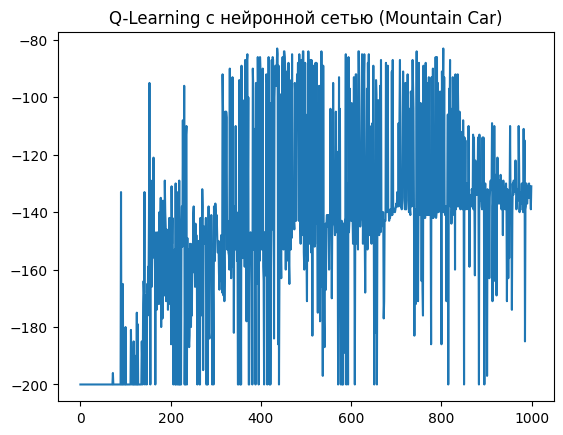

In [ ]:
class NNEstimator():
    def __init__(self, n_feat, n_state, n_action, n_hidden=50, lr=0.001):
        self.n_feat = n_feat
        torch.manual_seed(0)
        self.w = torch.randn((n_state, n_feat)) * 5.0
        self.b = torch.rand(n_feat) * 2.0 * math.pi

        self.models = []
        self.optimizers = []
        self.criterion = torch.nn.MSELoss()

        for _ in range(n_action):
            # Нейронная сеть: Вход(n_feat) -> Скрытый(n_hidden) -> ReLU -> Выход(1)
            model = torch.nn.Sequential(
                torch.nn.Linear(n_feat, n_hidden),
                torch.nn.ReLU(),
                torch.nn.Linear(n_hidden, 1)
            )
            self.models.append(model)
            # Используем Adam вместо SGD
            self.optimizers.append(torch.optim.Adam(model.parameters(), lr))

    def get_feature(self, s):
        if isinstance(s, tuple): s = s[0]
        s_tensor = torch.as_tensor(s).float().view(-1)
        return (2.0 / self.n_feat) ** .5 * torch.cos(torch.matmul(s_tensor, self.w) + self.b)

    def update(self, s, a, y):
        features = self.get_feature(s)
        y_pred = self.models[a](features)
        loss = self.criterion(y_pred, torch.tensor([y]).float())

        self.optimizers[a].zero_grad()
        loss.backward()
        self.optimizers[a].step()

    def predict(self, s):
        features = self.get_feature(s)
        with torch.no_grad():
            return torch.tensor([model(features).item() for model in self.models])

# Обучение нейросети в Mountain Car
nn_estimator = NNEstimator(200, n_state, n_action, n_hidden=50, lr=0.001)
rewards_nn = q_learning_replay(env, nn_estimator, n_episode=1000, replay_size=200)

plt.plot(rewards_nn)
plt.title('Q-Learning с нейронной сетью (Mountain Car)')
plt.show()

Решение задачи балансирования стержня (CartPole)

Действий в CartPole: 2
Эпизод 50, Награда: 12.0
Эпизод 100, Награда: 105.0
Эпизод 150, Награда: 17.0
Эпизод 200, Награда: 500.0
Эпизод 250, Награда: 364.0
Эпизод 300, Награда: 500.0


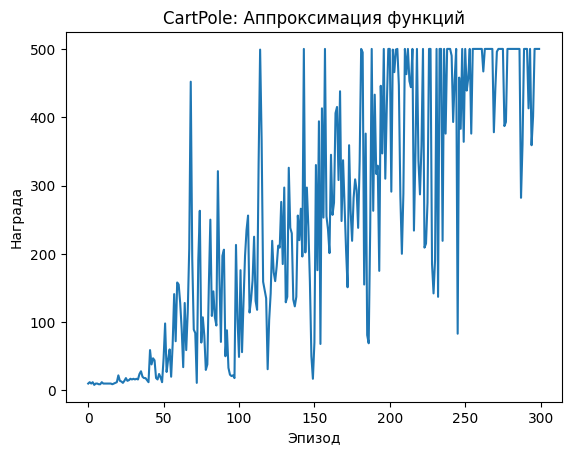

In [ ]:
# 1. Создаем среду CartPole заново
env_cp = gym.make("CartPole-v1")
n_state_cp = env_cp.action_space.shape # это для проверки, но лучше так:
n_state_cp = env_cp.observation_space.shape[0]
n_action_cp = env_cp.action_space.n # Здесь будет 2!

print(f"Действий в CartPole: {n_action_cp}") # Должно напечатать 2

# 2. Создаем новый Estimator специально для CartPole
# Увеличиваем n_feat до 400 и n_hidden до 100 для лучшего результата
cp_estimator = NNEstimator(n_feat=400, n_state=n_state_cp, n_action=n_action_cp, n_hidden=100, lr=0.01)

# 3. Обновленная функция запуска (явно передаем n_action_cp)
def q_learning_cp(env, estimator, n_episode, n_action_env, gamma=1.0, epsilon=0.1, epsilon_decay=0.99):
    total_reward_episode = []

    for episode in range(n_episode):
        curr_eps = epsilon * (epsilon_decay ** episode)

        # ВНИМАНИЕ: Передаем n_action_env (2 для CartPole), а не глобальное n_action
        policy = gen_epsilon_greedy_policy(estimator, curr_eps, n_action_env)

        obs = env.reset()
        state = obs[0] if isinstance(obs, tuple) else obs
        is_done = False
        total_reward = 0

        while not is_done:
            action = policy(state)
            step_res = env.step(action)
            next_state, reward = step_res[0], step_res[1]

            if len(step_res) == 5:
                is_done = step_res[2] or step_res[3]
            else:
                is_done = step_res[2]

            q_values_next = estimator.predict(next_state)
            td_target = reward + gamma * torch.max(q_values_next).item()

            estimator.update(state, action, td_target)

            total_reward += reward
            state = next_state

        total_reward_episode.append(total_reward)
        if (episode + 1) % 50 == 0:
            print(f"Эпизод {episode+1}, Награда: {total_reward}")

    return total_reward_episode

# 4. Запускаем обучение для CartPole
rewards_cp = q_learning_cp(env_cp, cp_estimator, n_episode=300, n_action_env=n_action_cp)

# 5. График
import matplotlib.pyplot as plt
plt.plot(rewards_cp)
plt.title('CartPole: Аппроксимация функций')
plt.xlabel('Эпизод')
plt.ylabel('Награда')
plt.show()